Total Revenue: 8911407.9
Total Orders: 18532
Total Customers: 4338


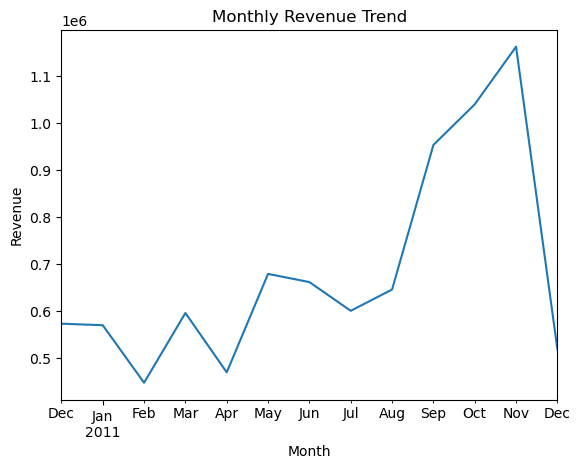

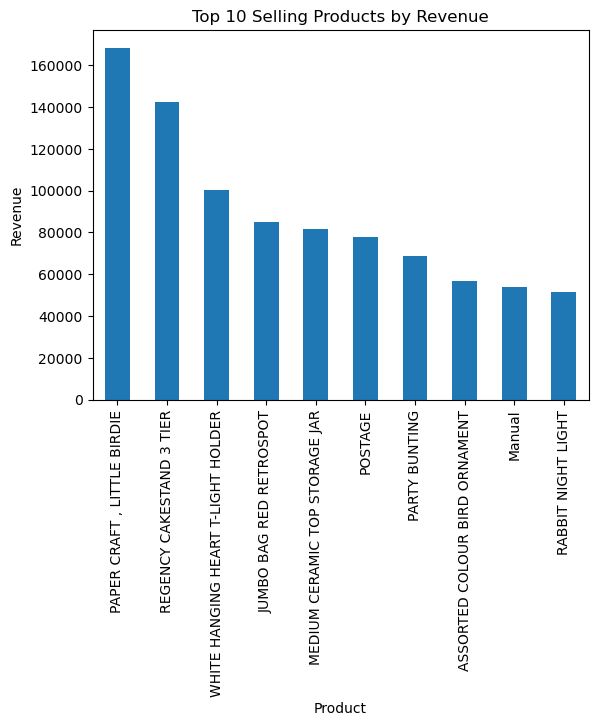

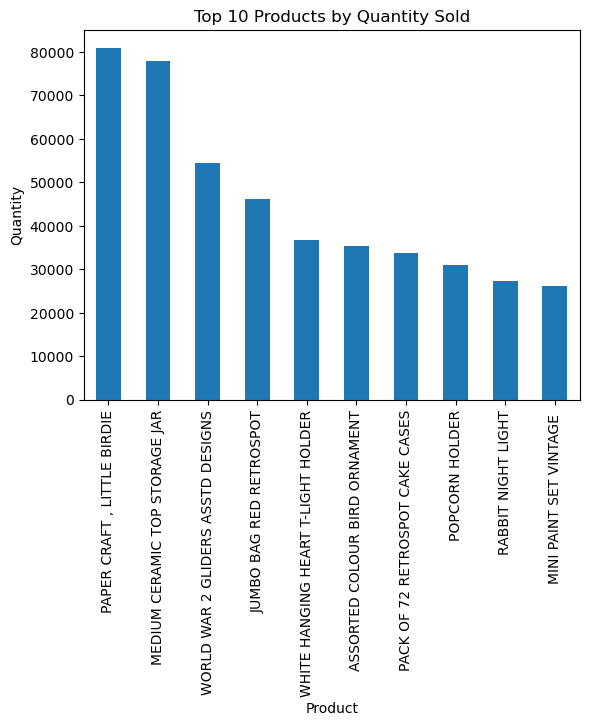

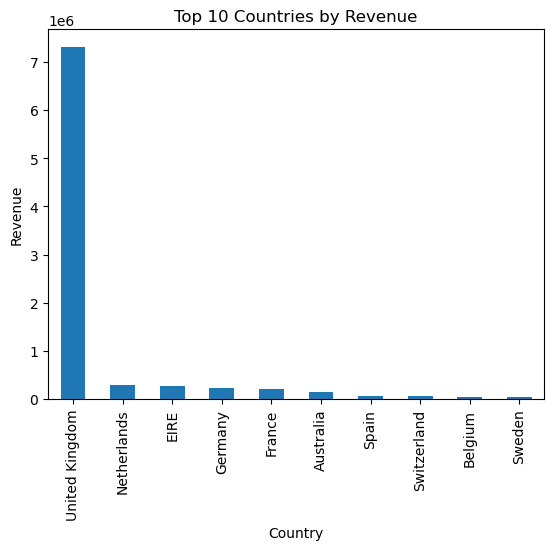

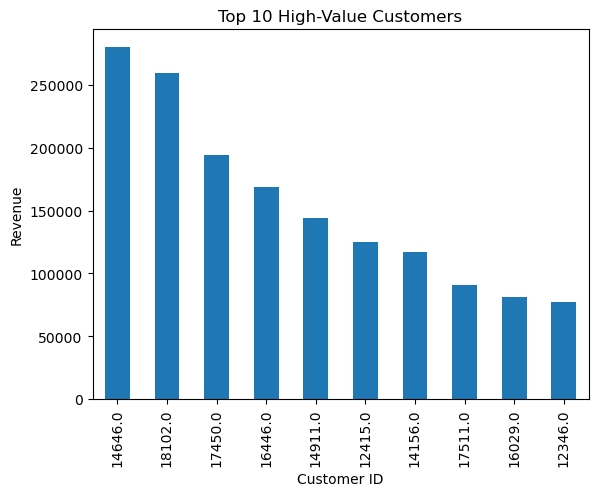

Business Sales Analysis Completed Successfully


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv( r'C:\Users\Irene Rachel\Desktop\data.csv', encoding='latin1')
df.dropna(inplace=True)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.to_period('M')
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
monthly_revenue = df.groupby('Month')['Revenue'].sum()
plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()
top_products = (df.groupby('Description')['Revenue'].sum().sort_values(ascending=False) .head(10))
plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()
top_quantity_products = ( df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10))
plt.figure()
top_quantity_products.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()
country_revenue = (df.groupby('Country')['Revenue'] .sum() .sort_values(ascending=False).head(10))
plt.figure()
country_revenue.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()
top_customers = (df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False) .head(10))
plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 10 High-Value Customers")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()
summary = { "Total Revenue": [total_revenue],"Total Orders": [total_orders], "Total Customers": [total_customers]}
summary_df = pd.DataFrame(summary)
summary_df.to_csv("business_sales_summary.csv", index=False)
print("Business Sales Analysis Completed Successfully")
